### Demo: Primal and Dual Representation of Linear Regression

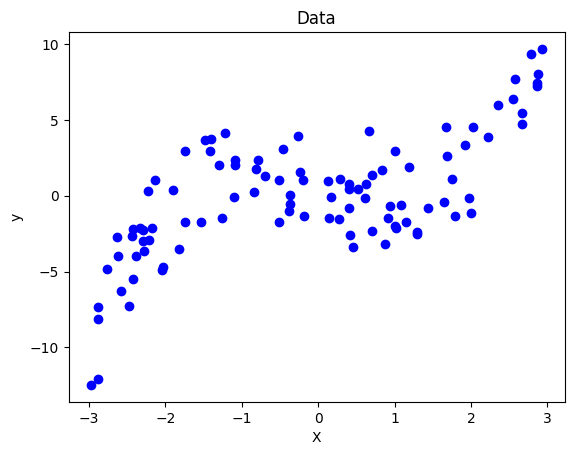

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 100
X = np.random.uniform(-3, 3, size=(n, 1))
X = np.sort(X, axis=0)
y = 0.5 * X[:,0]**3 - X[:,0] + np.random.normal(scale=2, size=n)

def display_data(X, y, y_pred=None):
    plt.scatter(X, y, color='blue', label='Data')
    if y_pred is not None:
        plt.plot(X, y_pred, color='red', label='Prediction')
    plt.xlabel('X')
    plt.ylabel('y')

display_data(X, y)
plt.title("Data")
plt.show()

In [2]:
class LinearRegressionPrimal:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)

        for _ in range(self.epochs):

            pred = self.w @ X.T
            error = pred - y

            grad = error @ X / n

            self.w -= self.lr * grad

    def predict(self, X):
        return self.w @ X.T

In [3]:
class LinearRegressionDual:
    def __init__(self, lr=0.01, epochs=100, kernel=None):
        self.lr = lr
        self.epochs = epochs
        self.kernel = kernel
        if self.kernel is None:
            self.kernel = lambda X, Y: X @ Y.T

    def fit(self, X, y):
        self.X_train = X
        n, _ = X.shape
        self.alpha = np.zeros(n)

        K = self.kernel(X, X)

        for _ in range(self.epochs):

            pred = self.alpha @ K.T
            error = pred - y

            grad = (error @ K) / n

            self.alpha -= self.lr * grad

    def predict(self, X):
        K = self.kernel(X, self.X_train)
        return self.alpha @ K.T

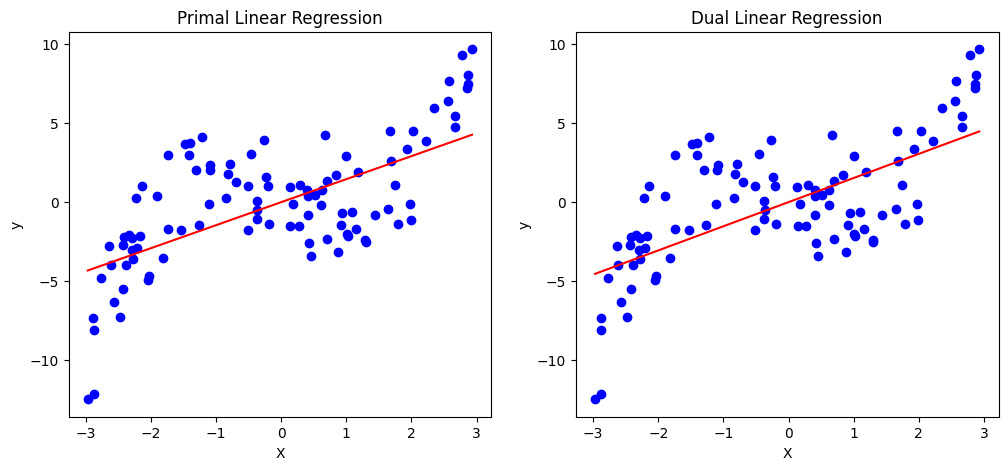

In [4]:
# Linear kernel
primal = LinearRegressionPrimal(lr=0.01, epochs=100)
primal.fit(X, y)
y_pred_primal = primal.predict(X)
dual = LinearRegressionDual(lr=0.001, epochs=100)
dual.fit(X, y)
y_pred_dual = dual.predict(X)

# Two subplots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Primal Linear Regression')
display_data(X, y, y_pred_primal)
plt.subplot(1, 2, 2)
plt.title('Dual Linear Regression')
display_data(X, y, y_pred_dual)


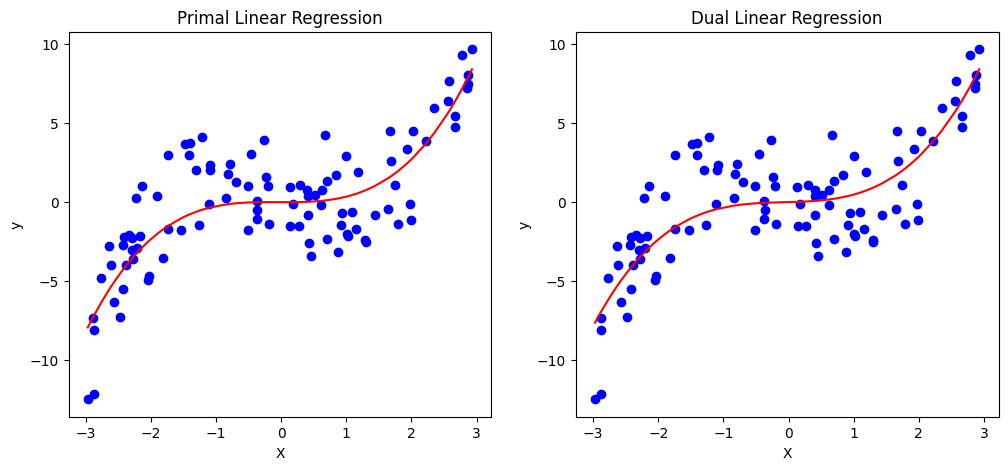

In [5]:
# Polynomial kernel of degree 3
primal = LinearRegressionPrimal(lr=0.001, epochs=100)
X_transformed = np.hstack([
    X,
    X**2,
    X**3
])
primal.fit(X_transformed, y)
y_pred_primal = primal.predict(X_transformed)
kernel = lambda X, Y: (X @ Y.T + 1)**3
dual = LinearRegressionDual(lr=1e-6, epochs=100, kernel=kernel)
dual.fit(X, y)
y_pred_dual = dual.predict(X)

# Two subplots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Primal Linear Regression')
display_data(X, y, y_pred_primal)
plt.subplot(1, 2, 2)
plt.title('Dual Linear Regression')
display_data(X, y, y_pred_dual)


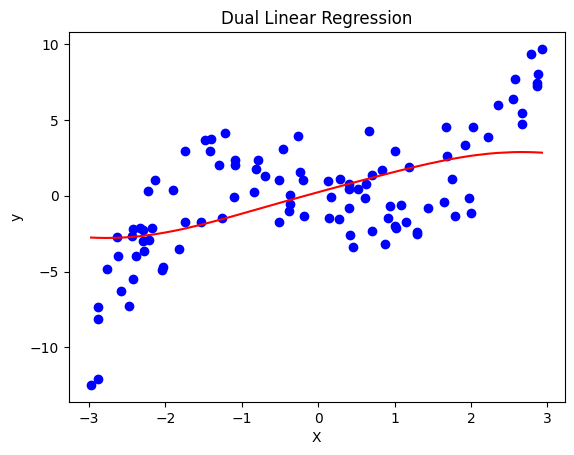

In [6]:
# RBF kernel, primal doesn't work anymore
kernel = lambda X, Y: np.exp(-0.2 * np.sum((X[:, None] - Y[None])**2, axis=2))
dual = LinearRegressionDual(lr=0.01, epochs=100, kernel=kernel)
dual.fit(X, y)
y_pred_dual = dual.predict(X)

plt.title('Dual Linear Regression')
display_data(X, y, y_pred_dual)